
--- Stage 1/4: Training on original data ---
Epoch 1/25, Train Loss: 0.070830, Val Loss: 0.037315
Epoch 2/25, Train Loss: 0.032683, Val Loss: 0.026815
Epoch 3/25, Train Loss: 0.026417, Val Loss: 0.023410
Epoch 4/25, Train Loss: 0.023350, Val Loss: 0.021330
Epoch 5/25, Train Loss: 0.022758, Val Loss: 0.021344
Epoch 6/25, Train Loss: 0.020555, Val Loss: 0.018755
Epoch 7/25, Train Loss: 0.018894, Val Loss: 0.017034
Epoch 8/25, Train Loss: 0.017469, Val Loss: 0.016374
Epoch 9/25, Train Loss: 0.015689, Val Loss: 0.015437
Epoch 10/25, Train Loss: 0.015938, Val Loss: 0.014588
Epoch 11/25, Train Loss: 0.015841, Val Loss: 0.014547
Epoch 12/25, Train Loss: 0.014937, Val Loss: 0.013516
Epoch 13/25, Train Loss: 0.013822, Val Loss: 0.015077
Epoch 14/25, Train Loss: 0.013521, Val Loss: 0.011599
Epoch 15/25, Train Loss: 0.013339, Val Loss: 0.013599
Epoch 16/25, Train Loss: 0.013946, Val Loss: 0.012914
Epoch 17/25, Train Loss: 0.012860, Val Loss: 0.012112
Epoch 18/25, Train Loss: 0.013750, Val Loss: 

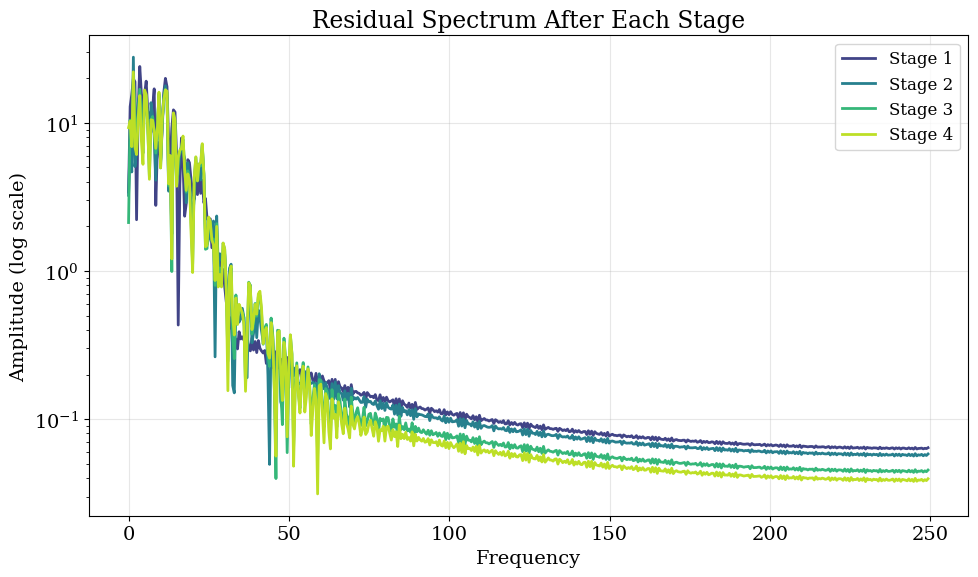

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from core import (
    set_seed, generate_multifreq_data, load_data,
    ResidualQuantumLearner, generate_clean_grid
)

def residual_spectrum(learner, components, x_range, n_points=1000):
    """Compute FFT of residuals after each stage on a clean grid."""
    x_grid, y_clean = generate_clean_grid(components, x_range, n_points)
    dx = x_grid[1] - x_grid[0]
    freqs = np.fft.fftfreq(n_points, d=dx)[:n_points//2]

    # Predictions at each stage
    preds = []
    for stage in range(1, learner.n_stages + 1):
        pred = learner.predict(torch.tensor(x_grid.reshape(-1, 1), dtype=torch.float32), stage=stage)
        preds.append(pred.numpy().flatten())

    # Compute FFT of residuals
    fft_residuals = []
    for i, pred in enumerate(preds):
        residual = y_clean - pred
        fft_vals = np.abs(np.fft.fft(residual)[:n_points//2])
        fft_residuals.append(fft_vals)

    return freqs, fft_residuals


if __name__ == "__main__":
    # -------------------- Configuration --------------------
    config = {
        'seed': 42,
        'data': {
            'n_samples': 5000,
            'x_range': (0, 2.0),
            'noise': 0.0,
            'components': [
                {'freq': 0.5, 'center': 0.3, 'width': 0.2, 'amp': 1.0},
                {'freq': 3.0, 'center': 0.8, 'width': 0.15, 'amp': 0.7,
                 'envelope': lambda x, c, w: 1 / (1 + ((x - c)/w)**2)},
                {'freq': 7.0, 'center': 1.2, 'width': 0.25, 'amp': 0.5,
                 'envelope': lambda x, c, w: np.maximum(0, 1 - np.abs(x - c)/w)},
                {'freq': 12.0, 'center': 1.7, 'width': 0.1, 'amp': 0.3},
                {'freq': 20.0, 'center': 1.9, 'width': 0.05, 'amp': 0.2},
            ],
        },
        'training': {
            'batch_size': 64,
            'val_split': 0.15,
            'test_split': 0.15,
        },
        'model': {
            'input_dim': 1,
            'n_qubits': 6,          # moderate qubit count
            'n_layers': 2,
        },
        'optim': {
            'lr': 0.005,
            'epochs': 25,
        },
        'residual': {
            'n_stages': 4,
        },
    }

    set_seed(config['seed'])

    # -------------------- Generate data --------------------
    X, y = generate_multifreq_data(
        n_samples=config['data']['n_samples'],
        x_range=config['data']['x_range'],
        noise=config['data']['noise'],
        components=config['data']['components'],
        random_state=config['seed']
    )

    train_loader, val_loader, test_loader, _, _ = load_data(
        X, y,
        batch_size=config['training']['batch_size'],
        val_split=config['training']['val_split'],
        test_split=config['training']['test_split']
    )

    # -------------------- Train residual learner --------------------
    learner = ResidualQuantumLearner(
        input_dim=config['model']['input_dim'],
        n_qubits=config['model']['n_qubits'],
        n_layers=config['model']['n_layers'],
        lr=config['optim']['lr'],
        epochs=config['optim']['epochs'],
        n_stages=config['residual']['n_stages']
    )
    learner.fit(train_loader, val_loader)

    # -------------------- Compute residual spectra --------------------
    freqs, fft_residuals = residual_spectrum(
        learner,
        config['data']['components'],
        config['data']['x_range'],
        n_points=1000
    )

    # -------------------- Plot --------------------
    plt.figure(figsize=(10, 6))
    plt.rcParams['font.size'] = 14
    plt.rcParams['lines.linewidth'] = 2
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['figure.titlesize'] = 14
    plt.rcParams['font.family'] = 'serif'

    stage_colors = plt.cm.viridis(np.linspace(0.2, 0.9, learner.n_stages))
    for i, fft_res in enumerate(fft_residuals):
        plt.semilogy(freqs, fft_res, color=stage_colors[i], label=f'Stage {i+1}')

    plt.xlabel('Frequency')
    plt.ylabel('Amplitude (log scale)')
    plt.title('Residual Spectrum After Each Stage')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save figures
    plt.savefig('experiment_residual_spectrum.png', dpi=300)
    plt.savefig('experiment_residual_spectrum.pdf', dpi=300)
    plt.show()

In [ ]:
freqs

array([  0.    ,   0.4995,   0.999 ,   1.4985,   1.998 ,   2.4975,
         2.997 ,   3.4965,   3.996 ,   4.4955,   4.995 ,   5.4945,
         5.994 ,   6.4935,   6.993 ,   7.4925,   7.992 ,   8.4915,
         8.991 ,   9.4905,   9.99  ,  10.4895,  10.989 ,  11.4885,
        11.988 ,  12.4875,  12.987 ,  13.4865,  13.986 ,  14.4855,
        14.985 ,  15.4845,  15.984 ,  16.4835,  16.983 ,  17.4825,
        17.982 ,  18.4815,  18.981 ,  19.4805,  19.98  ,  20.4795,
        20.979 ,  21.4785,  21.978 ,  22.4775,  22.977 ,  23.4765,
        23.976 ,  24.4755,  24.975 ,  25.4745,  25.974 ,  26.4735,
        26.973 ,  27.4725,  27.972 ,  28.4715,  28.971 ,  29.4705,
        29.97  ,  30.4695,  30.969 ,  31.4685,  31.968 ,  32.4675,
        32.967 ,  33.4665,  33.966 ,  34.4655,  34.965 ,  35.4645,
        35.964 ,  36.4635,  36.963 ,  37.4625,  37.962 ,  38.4615,
        38.961 ,  39.4605,  39.96  ,  40.4595,  40.959 ,  41.4585,
        41.958 ,  42.4575,  42.957 ,  43.4565,  43.956 ,  44.4

In [ ]:
fft_res

array([ 9.283919  , 10.281858  ,  6.9099646 , 22.088089  ,  6.853749  ,
        6.1072116 , 10.709241  , 15.280185  ,  7.5855474 ,  5.2486987 ,
       16.651743  , 15.524267  ,  9.178284  ,  4.1587763 , 10.489568  ,
       10.407139  ,  8.8106575 ,  6.7318244 ,  9.1784315 , 16.109177  ,
        4.956555  , 10.5888195 , 14.289609  , 16.695227  , 16.342781  ,
        3.8677754 ,  6.020983  ,  1.2060446 , 11.681611  , 10.466715  ,
        3.7298079 ,  5.8013954 ,  6.5404944 ,  6.6975627 ,  8.143526  ,
        4.8132224 ,  3.4967072 ,  4.5199885 ,  4.069008  ,  1.8347882 ,
        0.97589713,  4.3217726 ,  5.8984137 ,  4.05818   ,  5.2636943 ,
        5.3778973 ,  7.2329793 ,  4.542586  ,  1.4553341 ,  1.4909683 ,
        2.3119843 ,  2.1503024 ,  1.6188586 ,  1.5020981 ,  0.8618118 ,
        1.9996046 ,  0.78023833,  0.94420975,  0.780021  ,  1.5436418 ,
        1.4131285 ,  0.74325395,  0.15553951,  0.92786986,  1.0784496 ,
        0.49123335,  0.369491  ,  0.6569917 ,  0.43517092,  0.59